# **1. Perkenalan Dataset**

**Nama Dataset:** Ultimate Memory Crisis Hardware Market Dynamics

**Sumber:** Kaggle — [moaz1911](https://www.kaggle.com/datasets/moaz1911/ultimate-memory-crisis-hardware-market-dynamics)

**Deskripsi:** Dataset simulasi pasar memori RAM yang mencakup spesifikasi teknis (DDR4/DDR5/DDR6-Preview), harga, dan kondisi pasar global di berbagai region. Berisi 10.000 baris dan 28 kolom.

**Jenis Masalah:** Regresi — prediksi `price_usd`

**Kolom Target:** `price_usd`

# **2. Import Library**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: '%.4f' % x)
plt.style.use('seaborn-v0_8-darkgrid')

# **3. Memuat Dataset**

In [2]:
df = pd.read_csv('../memory_crisis_raw/datasets_raw.csv')

print('Shape:', df.shape)
df.head()

Shape: (10000, 28)


,kit_id,brand,model_name,timestamp,region,generation,form_factor,capacity_gb,module_count,is_ecc,speed_mts,cas_latency,voltage,timing_string,die_manufacturer,die_type,true_latency_ns,bandwidth_per_dollar,latency_value_index,speed_premium_ratio,price_per_gb,price_usd,market_segment,recommended_usage,price_status,global_inventory_weeks,fab_utilization_rate,gpu_hbm_trend_gb
0,MPN-000000,Mushkin,Mushkin DDR5 6400MT/s,2026-05-13,EMEA,DDR5,DIMM,512,2,False,6400,42,1.1000,42-44-44-88,Samsung,B-Die,13.1250,1.6169,415610.0300,8.8352,61.8500,31665.5300,Enterprise/AI,AI / Data Science,Shortage-Inflated,5.9800,0.8543,236.8500
1,MPN-000001,Patriot,Patriot DDR6 (Preview) 16000MT/s,2025-09-15,Greater China,DDR6 (Preview),DIMM,32,4,False,16000,84,1.2000,84-86-86-172,Samsung,C-Die,10.5000,41.9456,32041.5300,3.4058,95.3600,3051.5700,Consumer,Gaming (AAA),Shortage-Inflated,7.8200,0.7558,182.1100
2,MPN-000002,Lexar,Lexar DDR6 (Preview) 12800MT/s,2024-08-27,Latin America,DDR6 (Preview),DIMM,128,2,False,12800,60,1.2000,60-62-62-124,Samsung,B-Die,9.3750,14.5198,66116.6500,1.9678,55.1000,7052.4400,Enterprise/AI,AI / Data Science,Normal,12.1800,0.5981,94.5200
3,MPN-000003,Lexar,Lexar DDR4 4400MT/s,2024-09-30,EMEA,DDR4,DIMM,128,1,False,4400,17,1.4000,17-19-19-38,Micron,R-Die,7.7273,43.9518,6188.6000,1.9553,6.2600,800.8800,Enterprise/AI,AI / Data Science,Normal,12.6400,0.6121,102.2700
4,MPN-000004,Lexar,Lexar DDR5 5600MT/s,2026-07-12,EMEA,DDR5,SODIMM,48,2,False,5600,32,1.4000,32-34-34-68,Samsung,E-Die,11.4286,26.3981,19395.3000,5.0509,35.3600,1697.0900,Consumer,Content Creation,Shortage-Inflated,5.3500,0.8790,250.5400


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 28 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   kit_id                  10000 non-null  object 
 1   brand                   10000 non-null  object 
 2   model_name              10000 non-null  object 
 3   timestamp               10000 non-null  object 
 4   region                  10000 non-null  object 
 5   generation              10000 non-null  object 
 6   form_factor             10000 non-null  object 
 7   capacity_gb             10000 non-null  int64  
 8   module_count            10000 non-null  int64  
 9   is_ecc                  10000 non-null  bool   
 10  speed_mts               10000 non-null  int64  
 11  cas_latency             10000 non-null  int64  
 12  voltage                 10000 non-null  float64
 13  timing_string           10000 non-null  object 
 14  die_manufacturer        10000 non-null 

In [4]:
df.describe()

,capacity_gb,module_count,speed_mts,cas_latency,voltage,true_latency_ns,bandwidth_per_dollar,latency_value_index,speed_premium_ratio,price_per_gb,price_usd,global_inventory_weeks,fab_utilization_rate,gpu_hbm_trend_gb
count,10000.0000,10000.0000,10000.0000,10000.0000,10000.0000,10000.0000,10000.0000,10000.0000,10000.0000,10000.0000,10000.0000,10000.0000,10000.0000,10000.0000
mean,122.0656,2.5409,6212.9413,32.2837,1.3088,11.0191,85.0398,49676.5863,4.4220,31.7499,4656.4776,9.0350,0.7236,164.2401
std,132.7100,1.5618,2985.4749,12.1081,0.1183,2.7081,149.4949,82860.2857,2.8483,34.2540,7741.2940,3.4957,0.1298,72.0875
min,8.0000,1.0000,2133.0000,14.0000,1.0000,5.7143,1.0045,161.4300,0.9602,3.0900,24.7500,2.0000,0.5000,40.0000
25%,32.0000,2.0000,4400.0000,22.0000,1.2500,9.0000,9.3108,4973.4775,1.9480,12.9100,439.7625,6.0300,0.6124,102.4425
50%,64.0000,2.0000,6000.0000,32.0000,1.3500,10.6250,27.5960,18083.5050,3.7883,21.2250,1702.2150,9.0650,0.7219,163.2900
75%,128.0000,2.0000,7600.0000,38.0000,1.4000,12.6667,88.4040,56853.1300,6.3168,41.6700,5433.5725,12.0100,0.8363,226.8200
max,512.0000,8.0000,21000.0000,84.0000,1.4500,20.6282,1395.8613,985954.5000,11.3059,310.4100,77157.3800,16.2000,0.9500,290.0000


# **4. Exploratory Data Analysis (EDA)**

Tujuan EDA adalah memahami karakteristik dataset sebelum preprocessing: distribusi fitur, korelasi, anomali, dan potensi masalah data.

### 4.1 Identifikasi Tipe Kolom

In [5]:
categorical_cols = df.select_dtypes(include=['object', 'string']).columns.tolist()
numerical_cols   = df.select_dtypes(include=['number']).columns.tolist()
bool_cols        = df.select_dtypes(include=['bool']).columns.tolist()

print('Kategorikal :', categorical_cols)
print('Numerik     :', numerical_cols)
print('Boolean     :', bool_cols)

Kategorikal : ['kit_id', 'brand', 'model_name', 'timestamp', 'region', 'generation', 'form_factor', 'timing_string', 'die_manufacturer', 'die_type', 'market_segment', 'recommended_usage', 'price_status']
Numerik     : ['capacity_gb', 'module_count', 'speed_mts', 'cas_latency', 'voltage', 'true_latency_ns', 'bandwidth_per_dollar', 'latency_value_index', 'speed_premium_ratio', 'price_per_gb', 'price_usd', 'global_inventory_weeks', 'fab_utilization_rate', 'gpu_hbm_trend_gb']
Boolean     : ['is_ecc']


### 4.2 Statistik Deskriptif per Fitur Kategorikal

In [6]:
cat_inspect = ['generation', 'brand', 'region', 'form_factor',
               'market_segment', 'recommended_usage', 'price_status',
               'die_manufacturer', 'die_type']

for col in cat_inspect:
    print(f'\n--- {col} ({df[col].nunique()} unique) ---')
    print(df[col].value_counts())


--- generation (3 unique) ---
generation
DDR5              7035
DDR4              2505
DDR6 (Preview)     460
Name: count, dtype: int64

--- brand (14 unique) ---
brand
Corsair          754
ADATA            748
SK Hynix         734
Mushkin          733
Samsung          733
Patriot          732
Silicon Power    711
Micron           707
TeamGroup        705
Lexar            701
Crucial          699
Pny              695
Kingston         684
G.Skill          664
Name: count, dtype: int64

--- region (6 unique) ---
region
Latin America    1725
Europe           1683
EMEA             1666
Greater China    1661
North America    1643
Asia-Pacific     1622
Name: count, dtype: int64

--- form_factor (3 unique) ---
form_factor
DIMM      6059
SODIMM    2930
LRDIMM    1011
Name: count, dtype: int64

--- market_segment (2 unique) ---
market_segment
Enterprise/AI    6446
Consumer         3554
Name: count, dtype: int64

--- recommended_usage (4 unique) ---
recommended_usage
AI / Data Science     4604


### 4.3 Distribusi Fitur Numerik

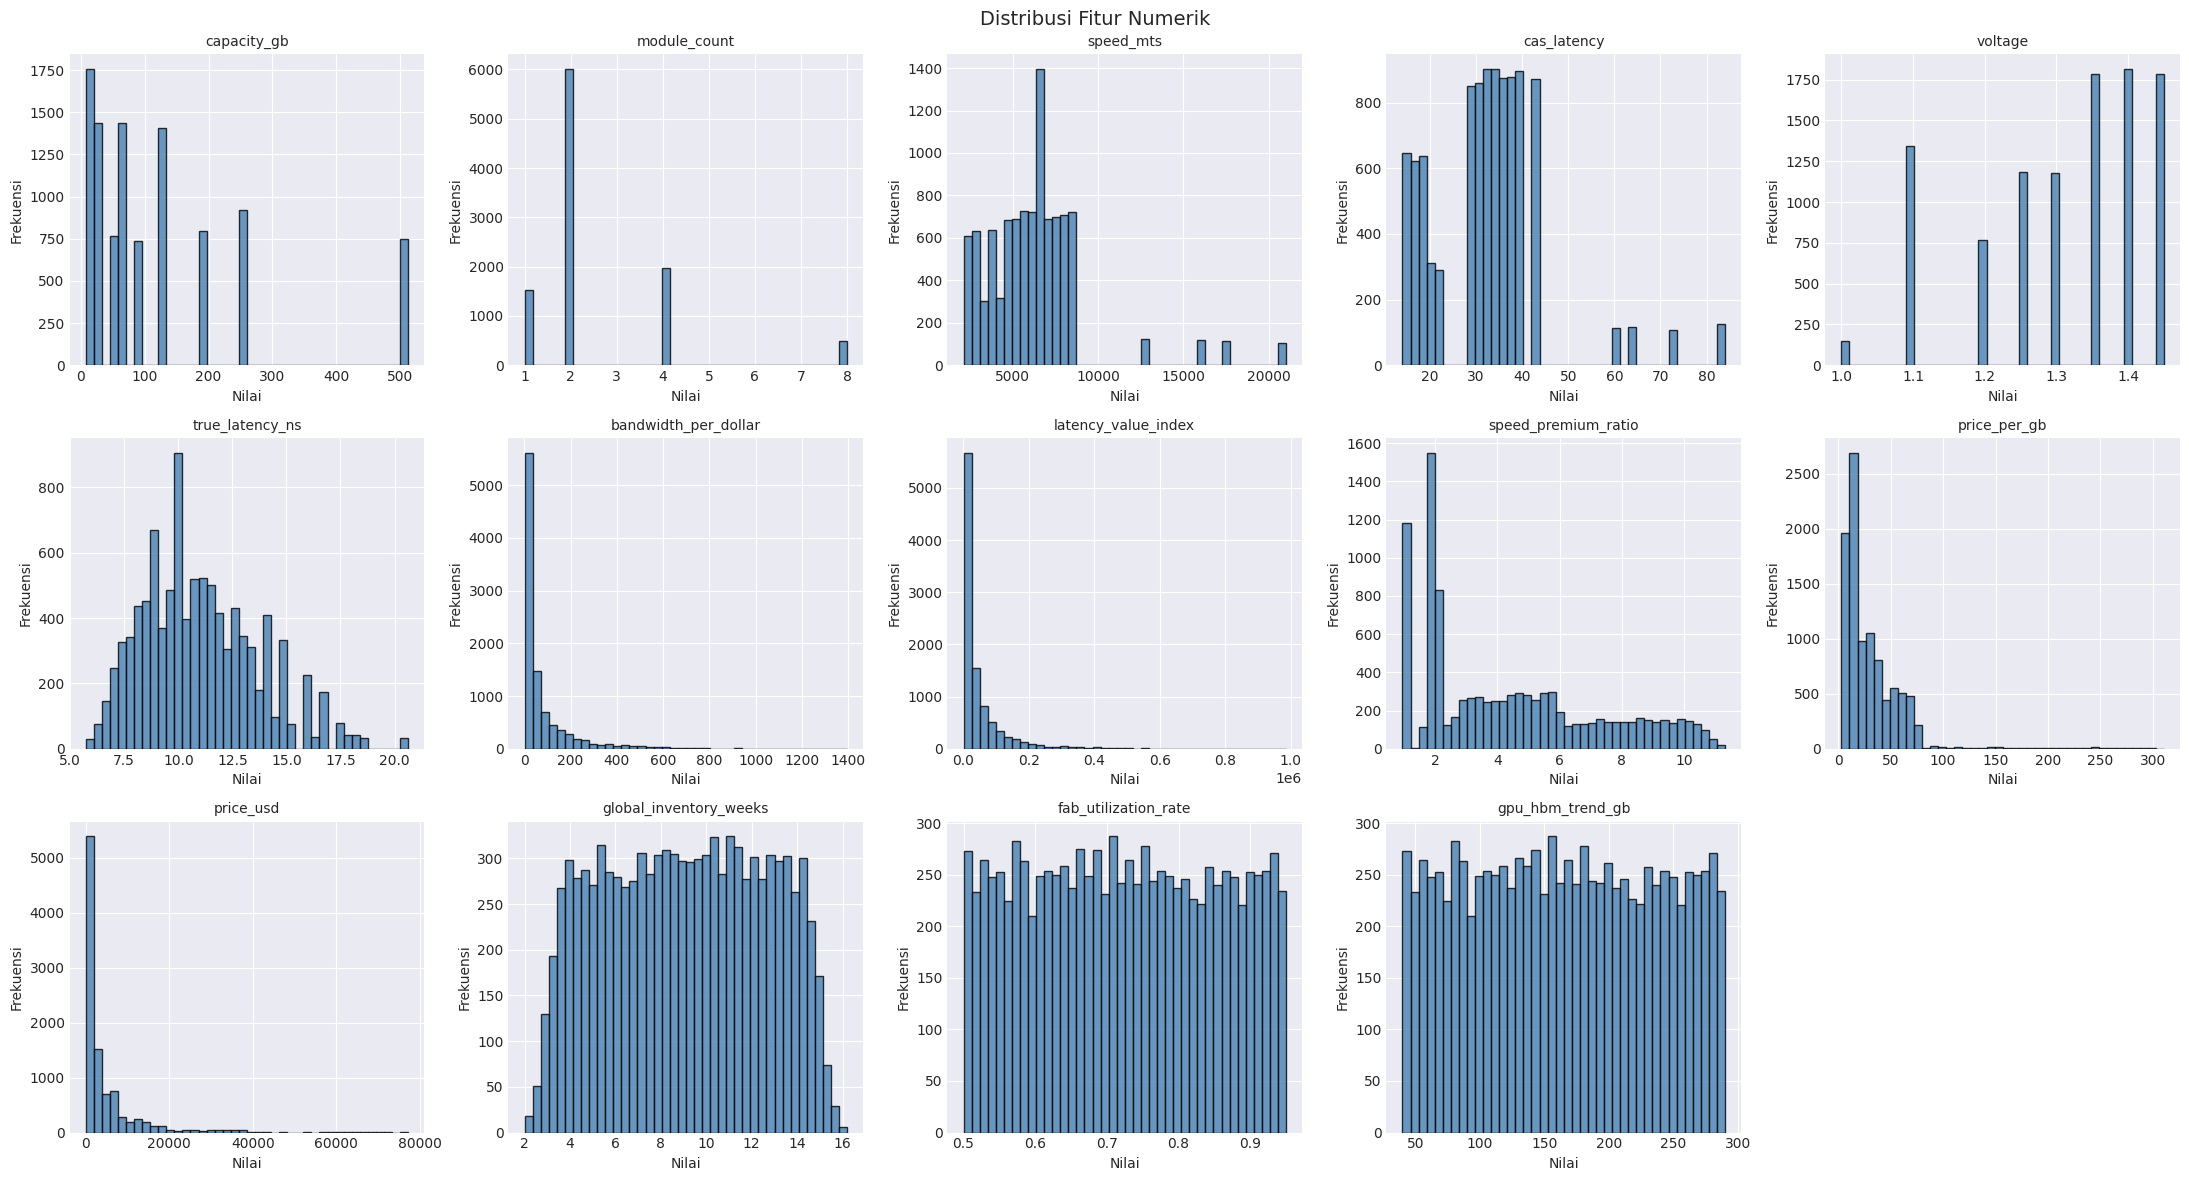

In [7]:
fig, axes = plt.subplots(3, 5, figsize=(22, 12))
axes = axes.flatten()

for i, col in enumerate(numerical_cols):
    axes[i].hist(df[col], bins=40, edgecolor='black', color='steelblue', alpha=0.8)
    axes[i].set_title(col, fontsize=10)
    axes[i].set_xlabel('Nilai')
    axes[i].set_ylabel('Frekuensi')

for j in range(len(numerical_cols), len(axes)):
    fig.delaxes(axes[j])

plt.suptitle('Distribusi Fitur Numerik', fontsize=14)
plt.tight_layout()
plt.show()

### 4.4 Distribusi Fitur Kategorikal

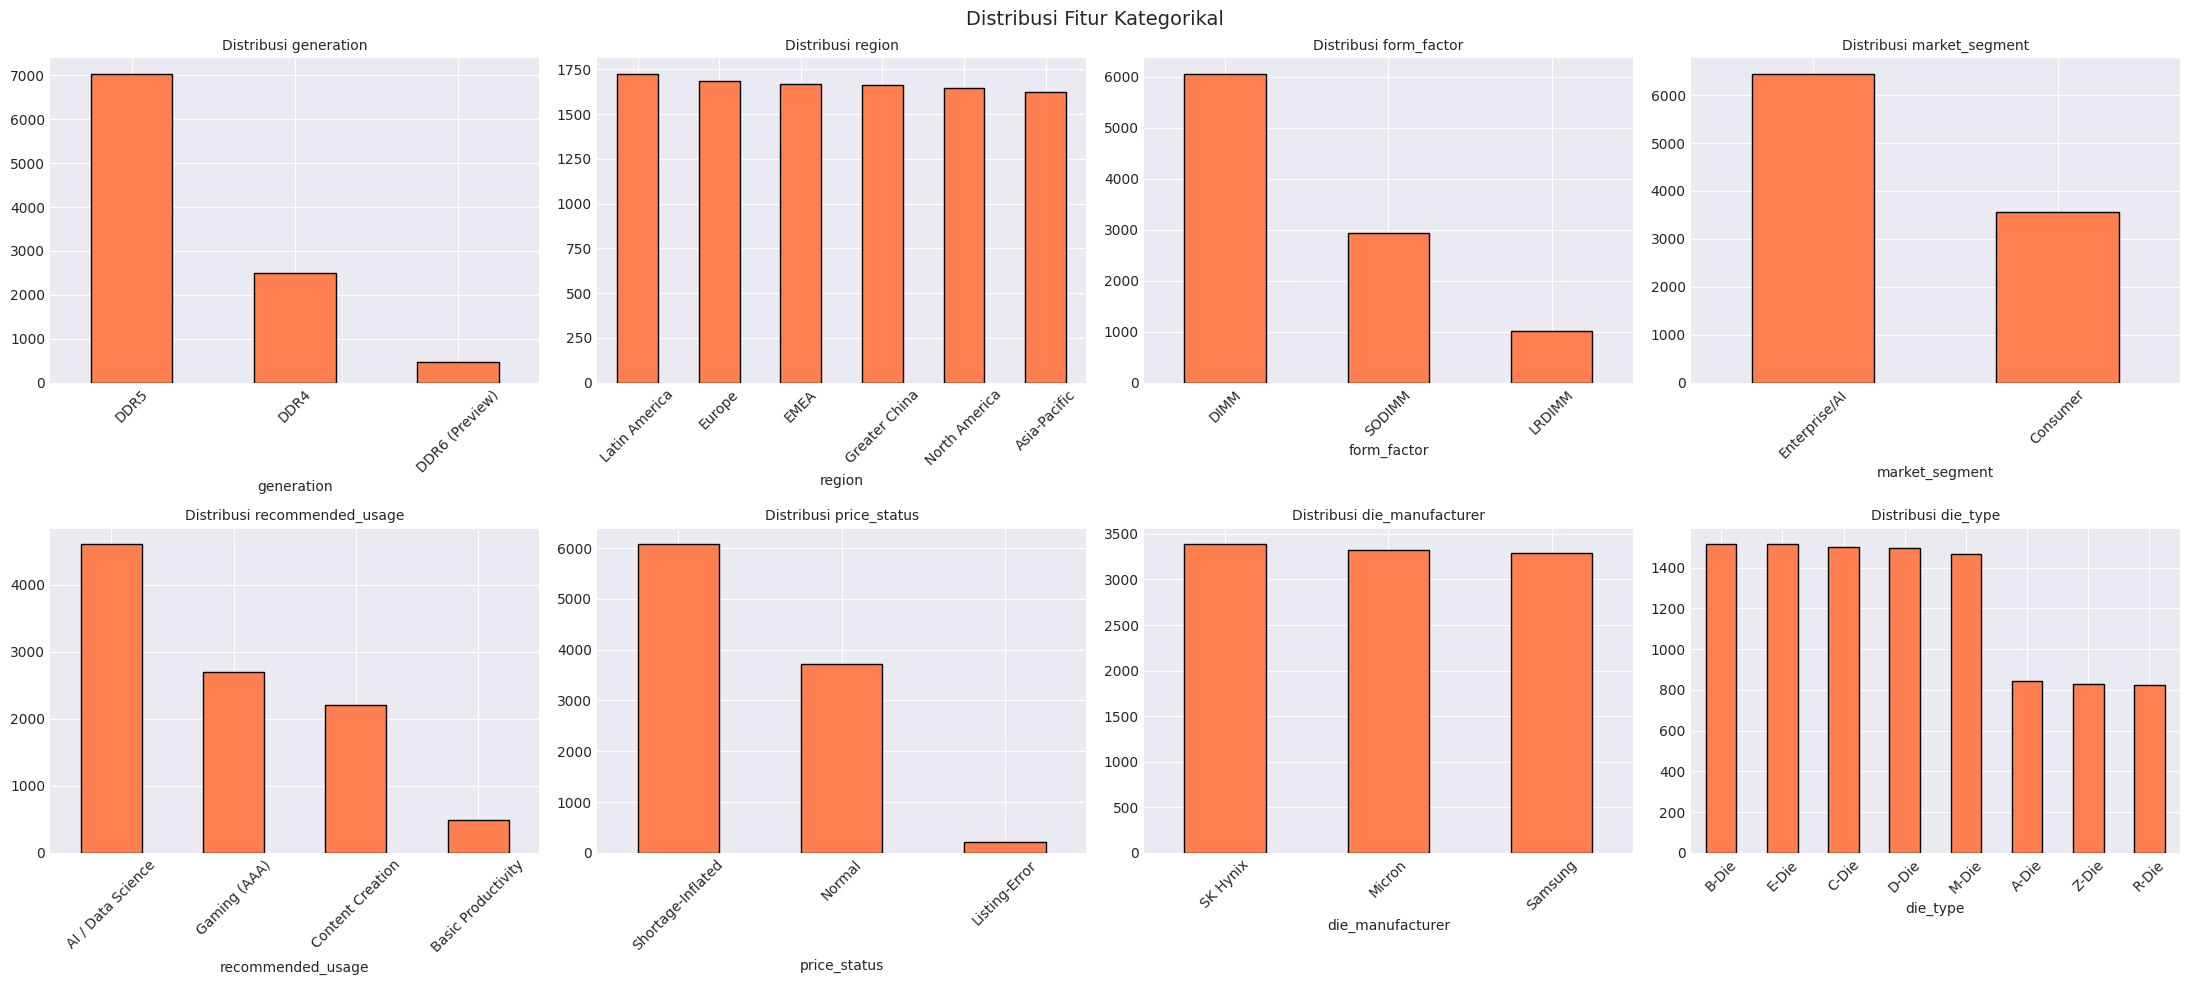

In [8]:
cat_plot_cols = ['generation', 'region', 'form_factor', 'market_segment',
                 'recommended_usage', 'price_status', 'die_manufacturer', 'die_type']

fig, axes = plt.subplots(2, 4, figsize=(22, 10))
axes = axes.flatten()

for i, col in enumerate(cat_plot_cols):
    df[col].value_counts().plot(kind='bar', ax=axes[i], color='coral', edgecolor='black')
    axes[i].set_title(f'Distribusi {col}', fontsize=10)
    axes[i].tick_params(axis='x', rotation=45)

plt.suptitle('Distribusi Fitur Kategorikal', fontsize=14)
plt.tight_layout()
plt.show()

### 4.5 Heatmap Korelasi Fitur Numerik

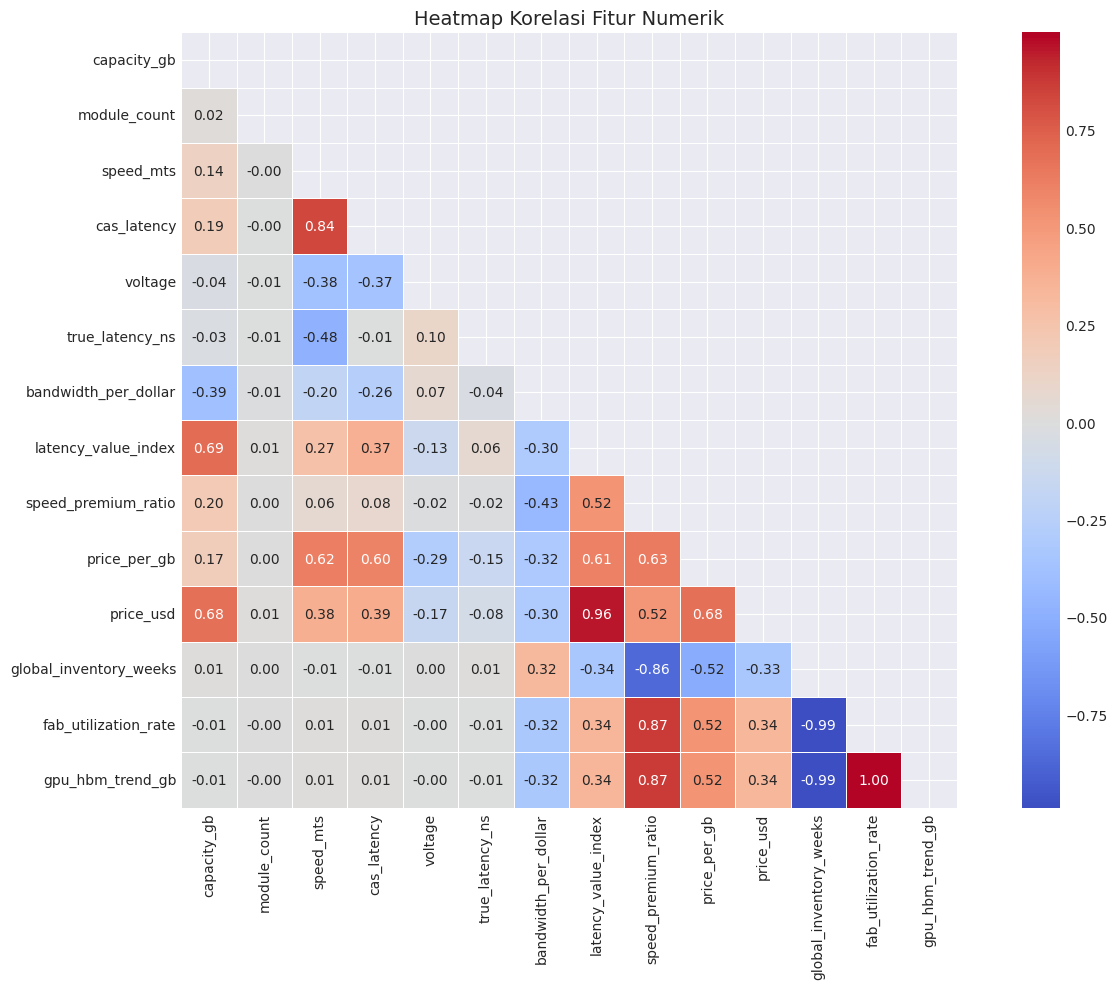

In [9]:
plt.figure(figsize=(14, 10))
corr_matrix = df[numerical_cols].corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(
    corr_matrix, mask=mask,
    annot=True, fmt='.2f',
    cmap='coolwarm', center=0,
    square=True, linewidths=0.5
)
plt.title('Heatmap Korelasi Fitur Numerik', fontsize=14)
plt.tight_layout()
plt.show()

In [10]:
# Korelasi terhadap target price_usd
print('Korelasi terhadap price_usd (diurutkan):')
print(corr_matrix['price_usd'].sort_values(ascending=False))

Korelasi terhadap price_usd (diurutkan):
price_usd                 1.0000
latency_value_index       0.9587
price_per_gb              0.6800
capacity_gb               0.6780
speed_premium_ratio       0.5159
cas_latency               0.3948
speed_mts                 0.3801
gpu_hbm_trend_gb          0.3363
fab_utilization_rate      0.3363
module_count              0.0072
true_latency_ns          -0.0779
voltage                  -0.1650
bandwidth_per_dollar     -0.2992
global_inventory_weeks   -0.3347
Name: price_usd, dtype: float64


### 4.6 Deteksi Outlier (Boxplot)

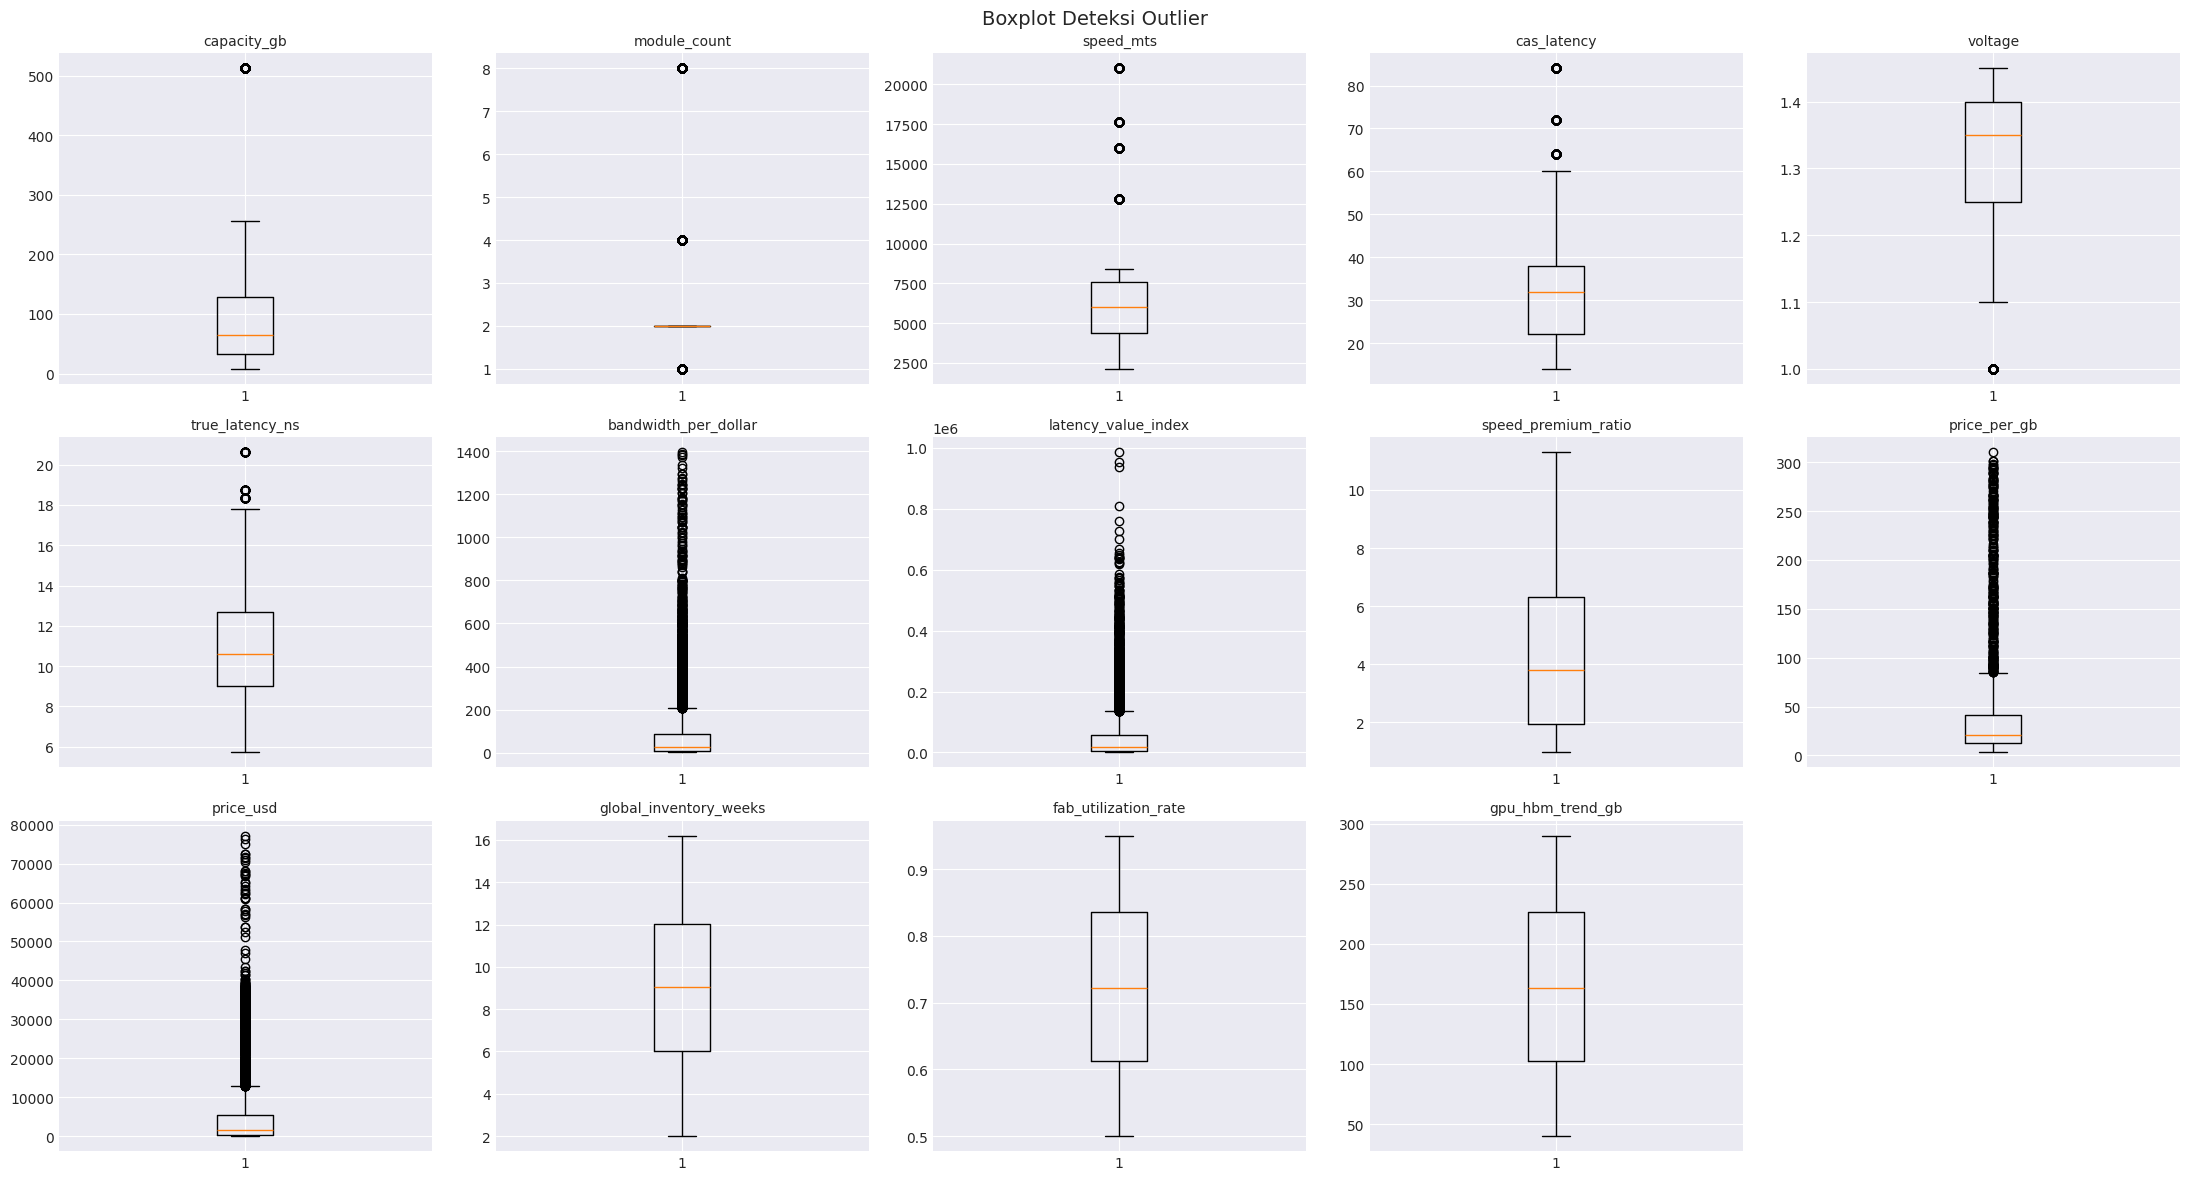

In [11]:
fig, axes = plt.subplots(3, 5, figsize=(22, 12))
axes = axes.flatten()

for i, col in enumerate(numerical_cols):
    axes[i].boxplot(df[col].dropna(), vert=True)
    axes[i].set_title(col, fontsize=10)

for j in range(len(numerical_cols), len(axes)):
    fig.delaxes(axes[j])

plt.suptitle('Boxplot Deteksi Outlier', fontsize=14)
plt.tight_layout()
plt.show()

In [12]:
# Hitung jumlah outlier per kolom dengan metode IQR
print('Jumlah outlier per kolom (metode IQR):')
for col in numerical_cols:
    Q1  = df[col].quantile(0.25)
    Q3  = df[col].quantile(0.75)
    IQR = Q3 - Q1
    n_outliers = df[(df[col] < Q1 - 1.5 * IQR) | (df[col] > Q3 + 1.5 * IQR)].shape[0]
    pct = n_outliers / len(df) * 100
    print(f'  {col:<30}: {n_outliers:>5} ({pct:.2f}%)')

Jumlah outlier per kolom (metode IQR):
  capacity_gb                   :   749 (7.49%)
  module_count                  :  3995 (39.95%)
  speed_mts                     :   460 (4.60%)
  cas_latency                   :   348 (3.48%)
  voltage                       :   151 (1.51%)
  true_latency_ns               :   107 (1.07%)
  bandwidth_per_dollar          :  1148 (11.48%)
  latency_value_index           :   982 (9.82%)
  speed_premium_ratio           :     0 (0.00%)
  price_per_gb                  :   294 (2.94%)
  price_usd                     :   974 (9.74%)
  global_inventory_weeks        :     0 (0.00%)
  fab_utilization_rate          :     0 (0.00%)
  gpu_hbm_trend_gb              :     0 (0.00%)


### 4.7 Identifikasi Missing Values dan Duplikat

In [13]:
print('Missing Values:')
missing = df.isnull().sum()
print(missing[missing > 0] if missing.any() else 'Tidak ada missing values.')

print(f'\nJumlah baris duplikat: {df.duplicated().sum()}')

Missing Values:
Tidak ada missing values.

Jumlah baris duplikat: 0


### 4.8 Temuan EDA

Berikut temuan yang relevan untuk keputusan preprocessing:

| Temuan | Detail | Aksi |
|---|---|---|
| Baris DDR6 (Preview) | 460 baris, generasi belum dirilis | Hapus seluruh baris |
| `latency_value_index` | Korelasi 0.959 dengan `price_usd` — derived feature | Hapus (leakage) |
| `price_per_gb` | = `price_usd / capacity_gb` | Hapus (leakage) |
| `bandwidth_per_dollar` | = `speed_mts / price_usd` | Hapus (leakage) |
| `speed_premium_ratio` | Formula berbasis harga | Hapus (leakage) |
| `kit_id` | ID unik, tidak informatif | Hapus |
| `model_name` | Mengandung info generation dan speed secara eksplisit | Hapus |
| `timing_string` | Redundant dengan `cas_latency`, `speed_mts` | Hapus |
| Missing values | Tidak ada | Tidak perlu aksi |
| Duplikat | Tidak ada | Tidak perlu aksi |
| Outlier | `bandwidth_per_dollar`, `latency_value_index`, `price_usd` — skewed kanan | Capping 1%-99% |

# **5. Data Preprocessing**

Tahapan preprocessing:
1. Menghapus baris DDR6 (Preview)
2. Menghapus kolom leakage dan tidak relevan
3. Menangani missing values
4. Menghapus data duplikat
5. Menangani outlier
6. Konversi boolean
7. Ekstrak fitur datetime
8. Encoding fitur kategorikal
9. Train-test split
10. Scaling fitur numerik
11. Simpan hasil

### 5.1 Hapus Baris DDR6 (Preview)

In [14]:
print(f'Shape sebelum: {df.shape}')

df = df[df['generation'] != 'DDR6 (Preview)'].copy()
df = df.reset_index(drop=True)

print(f'Shape setelah hapus DDR6: {df.shape}')
print('Generasi yang tersisa:', df['generation'].unique())

Shape sebelum: (10000, 28)
Shape setelah hapus DDR6: (9540, 28)
Generasi yang tersisa: ['DDR5' 'DDR4']


### 5.2 Hapus Kolom Leakage dan Tidak Relevan

In [15]:
cols_to_drop = [
    'kit_id',               # ID unik, tidak informatif
    'model_name',           # Terlalu spesifik, mengandung info yang sudah ada di kolom lain
    'timing_string',        # Redundant dengan cas_latency dan speed_mts
    'latency_value_index',  # Leakage: korelasi 0.959 dengan price_usd
    'price_per_gb',         # Leakage: derived dari price_usd / capacity_gb
    'bandwidth_per_dollar', # Leakage: derived dari speed_mts / price_usd
    'speed_premium_ratio',  # Leakage: formula berbasis harga
]

df.drop(columns=cols_to_drop, inplace=True)
print('Shape setelah drop kolom:', df.shape)
print('Kolom tersisa:', df.columns.tolist())

Shape setelah drop kolom: (9540, 21)
Kolom tersisa: ['brand', 'timestamp', 'region', 'generation', 'form_factor', 'capacity_gb', 'module_count', 'is_ecc', 'speed_mts', 'cas_latency', 'voltage', 'die_manufacturer', 'die_type', 'true_latency_ns', 'price_usd', 'market_segment', 'recommended_usage', 'price_status', 'global_inventory_weeks', 'fab_utilization_rate', 'gpu_hbm_trend_gb']


### 5.3 Penanganan Missing Values

In [16]:
print('Missing values per kolom:')
missing = df.isnull().sum()
print(missing[missing > 0] if missing.any() else 'Tidak ada missing values — tidak diperlukan imputasi.')

Missing values per kolom:
Tidak ada missing values — tidak diperlukan imputasi.


### 5.4 Penghapusan Data Duplikat

In [17]:
print(f'Jumlah duplikat: {df.duplicated().sum()}')
df.drop_duplicates(inplace=True)
df.reset_index(drop=True, inplace=True)
print(f'Shape setelah drop duplikat: {df.shape}')

Jumlah duplikat: 0
Shape setelah drop duplikat: (9540, 21)


### 5.5 Penanganan Outlier (Capping 1%-99%)

In [18]:
numerical_cols_current = df.select_dtypes(include='number').columns.tolist()

# Exclude target dari outlier capping agar distribusi target tidak dimanipulasi
cols_to_cap = [c for c in numerical_cols_current if c != 'price_usd']

print('Capping outlier (1st-99th percentile):')
for col in cols_to_cap:
    lower = df[col].quantile(0.01)
    upper = df[col].quantile(0.99)
    df[col] = df[col].clip(lower=lower, upper=upper)
    print(f'  {col:<35}: [{lower:.4f}, {upper:.4f}]')

print('\nCapping selesai.')

Capping outlier (1st-99th percentile):
  capacity_gb                        : [8.0000, 512.0000]
  module_count                       : [1.0000, 8.0000]
  speed_mts                          : [2133.0000, 8400.0000]
  cas_latency                        : [14.0000, 42.0000]
  voltage                            : [1.1000, 1.4500]
  true_latency_ns                    : [6.6667, 18.3333]
  global_inventory_weeks             : [2.8100, 15.1761]
  fab_utilization_rate               : [0.5041, 0.9455]
  gpu_hbm_trend_gb                   : [42.2800, 287.4900]

Capping selesai.


### 5.6 Konversi Boolean ke Integer

In [19]:
df['is_ecc'] = df['is_ecc'].astype(int)
print('is_ecc unique values:', df['is_ecc'].unique())
print('Dtype is_ecc:', df['is_ecc'].dtype)

is_ecc unique values: [0 1]
Dtype is_ecc: int64


### 5.7 Ekstrak Fitur dari Timestamp

In [20]:
df['timestamp'] = pd.to_datetime(df['timestamp'])
df['year']      = df['timestamp'].dt.year
df['month']     = df['timestamp'].dt.month
df.drop(columns=['timestamp'], inplace=True)

print('Fitur ditambahkan: year, month')
print('Kolom timestamp dihapus')
print('Shape:', df.shape)

Fitur ditambahkan: year, month
Kolom timestamp dihapus
Shape: (9540, 22)


### 5.8 Encoding Fitur Kategorikal

In [21]:
categorical_remaining = df.select_dtypes(include=['object', 'string']).columns.tolist()
print('Kolom kategorikal tersisa:', categorical_remaining)

print('\nJumlah unique value per kolom:')
for col in categorical_remaining:
    print(f'  {col}: {df[col].nunique()}')

Kolom kategorikal tersisa: ['brand', 'region', 'generation', 'form_factor', 'die_manufacturer', 'die_type', 'market_segment', 'recommended_usage', 'price_status']

Jumlah unique value per kolom:
  brand: 14
  region: 6
  generation: 2
  form_factor: 3
  die_manufacturer: 3
  die_type: 8
  market_segment: 2
  recommended_usage: 4
  price_status: 3


In [22]:
# One-Hot Encoding untuk semua kolom kategorikal
# drop_first=False agar seluruh kategori terwakili dan dapat diinterpretasi
df_encoded = pd.get_dummies(df, columns=categorical_remaining, drop_first=False)

# Pastikan semua kolom bool hasil OHE dikonversi ke int
ohe_bool_cols = df_encoded.select_dtypes(include='bool').columns.tolist()
df_encoded[ohe_bool_cols] = df_encoded[ohe_bool_cols].astype(int)

print('Shape setelah encoding:', df_encoded.shape)
print('Jumlah kolom fitur baru:', df_encoded.shape[1])

Shape setelah encoding: (9540, 58)
Jumlah kolom fitur baru: 58


### 5.9 Definisi Fitur (X) dan Target (y)

In [23]:
TARGET = 'price_usd'

X = df_encoded.drop(columns=[TARGET])
y = df_encoded[TARGET]

print('Shape X:', X.shape)
print('Shape y:', y.shape)
print('\nDeskripsi target (price_usd):')
print(y.describe())

Shape X: (9540, 57)
Shape y: (9540,)

Deskripsi target (price_usd):
count    9540.0000
mean     4079.6629
std      6383.8653
min        24.7500
25%       408.8600
50%      1574.2700
75%      4783.0675
max     40294.0300
Name: price_usd, dtype: float64


### 5.10 Train-Test Split

In [24]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print(f'X_train : {X_train.shape}')
print(f'X_test  : {X_test.shape}')
print(f'y_train : {y_train.shape}')
print(f'y_test  : {y_test.shape}')

X_train : (7632, 57)
X_test  : (1908, 57)
y_train : (7632,)
y_test  : (1908,)


### 5.11 Scaling Fitur Numerik (StandardScaler)

Scaler di-fit hanya pada X_train untuk mencegah data leakage dari test set.

In [25]:
# Kolom yang perlu di-scale: numerik kontinu dengan banyak nilai unik (bukan hasil OHE)
num_cols_to_scale = [
    'capacity_gb', 'module_count', 'speed_mts', 'cas_latency',
    'voltage', 'true_latency_ns',
    'global_inventory_weeks', 'fab_utilization_rate', 'gpu_hbm_trend_gb',
    'year', 'month'
]

# Filter kolom yang benar-benar ada
num_cols_to_scale = [c for c in num_cols_to_scale if c in X_train.columns]
print('Kolom yang di-scale:', num_cols_to_scale)

scaler = StandardScaler()
X_train[num_cols_to_scale] = scaler.fit_transform(X_train[num_cols_to_scale])
X_test[num_cols_to_scale]  = scaler.transform(X_test[num_cols_to_scale])

print('\nScaling selesai.')
print('X_train sample (5 kolom pertama):')
print(X_train[num_cols_to_scale[:5]].describe())

Kolom yang di-scale: ['capacity_gb', 'module_count', 'speed_mts', 'cas_latency', 'voltage', 'true_latency_ns', 'global_inventory_weeks', 'fab_utilization_rate', 'gpu_hbm_trend_gb', 'year', 'month']

Scaling selesai.
X_train sample (5 kolom pertama):
       capacity_gb  module_count  speed_mts  cas_latency   voltage
count    7632.0000     7632.0000  7632.0000    7632.0000 7632.0000
mean       -0.0000       -0.0000     0.0000       0.0000    0.0000
std         1.0001        1.0001     1.0001       1.0001    1.0001
min        -0.8502       -0.9872    -1.9418      -1.8859   -1.9810
25%        -0.6699       -0.3426    -0.7087      -0.9667   -0.6229
50%        -0.4294       -0.3426     0.1616       0.1824    0.2826
75%         0.0516       -0.3426     0.8143       0.8718    0.7353
max         2.9374        3.5249     1.4671       1.3315    1.1881


### 5.12 Verifikasi Akhir

In [26]:
print('=== Verifikasi Data Preprocessing ===')
print(f'X_train missing values : {X_train.isnull().sum().sum()}')
print(f'X_test  missing values : {X_test.isnull().sum().sum()}')
print(f'X_train shape          : {X_train.shape}')
print(f'X_test  shape          : {X_test.shape}')
print(f'y_train range          : [{y_train.min():.2f}, {y_train.max():.2f}]')
print(f'y_test  range          : [{y_test.min():.2f}, {y_test.max():.2f}]')
print('\nDtypes X_train:')
print(X_train.dtypes.value_counts())

=== Verifikasi Data Preprocessing ===
X_train missing values : 0
X_test  missing values : 0
X_train shape          : (7632, 57)
X_test  shape          : (1908, 57)
y_train range          : [24.76, 40294.03]
y_test  range          : [24.75, 39545.47]

Dtypes X_train:
int64      46
float64    11
Name: count, dtype: int64


### 5.13 Simpan Hasil Preprocessing

In [27]:
import os

output_dir = 'memory_crisis_preprocessing'
os.makedirs(output_dir, exist_ok=True)

X_train.to_csv(os.path.join(output_dir, 'X_train.csv'), index=False)
X_test.to_csv(os.path.join(output_dir,  'X_test.csv'),  index=False)
y_train.to_csv(os.path.join(output_dir, 'y_train.csv'), index=False, header=True)
y_test.to_csv(os.path.join(output_dir,  'y_test.csv'),  index=False, header=True)

print('Hasil disimpan ke:', output_dir)
print(f'  X_train.csv : {X_train.shape}')
print(f'  X_test.csv  : {X_test.shape}')
print(f'  y_train.csv : {y_train.shape}')
print(f'  y_test.csv  : {y_test.shape}')

Hasil disimpan ke: memory_crisis_preprocessing
  X_train.csv : (7632, 57)
  X_test.csv  : (1908, 57)
  y_train.csv : (7632,)
  y_test.csv  : (1908,)
